In [25]:
##load packages
##Set path
from pathlib import Path
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

base_dir = Path(r"D:\NTU_PSY\Documents\Patric_Asen_BrainHackProject")

In [26]:
import pandas as pd
from pathlib import Path

def load_and_filter_conditions(
    base_dir,
    sub_id,
    targets,
    filename="subject_fMRI_nii/sub-01_condition_with_ratings.csv",
    verbose=True
):
    """
    Load + filter + sort fMRI condition table
    """

    # -------------------------
    # 1. load data
    # -------------------------
    path = base_dir / filename.replace("sub-01", sub_id)
    df = pd.read_csv(path)

    # -------------------------
    # 2. filter concepts
    # -------------------------
    df_selected = df[df["concept"].isin(targets)].copy()

    # -------------------------
    # 3. ordering
    # -------------------------
    df_selected["concept"] = pd.Categorical(
        df_selected["concept"],
        categories=targets,
        ordered=True
    )

    df_selected = (
        df_selected
        .sort_values(by=["concept"])
        .reset_index(drop=True)
    )

    # -------------------------
    # 4. print (optional)
    # -------------------------
    if verbose:
        print(f"\n[{sub_id}] total selected:", len(df_selected))
        print(df_selected["concept"].value_counts())
        print(df_selected)

    return df_selected

In [27]:
df_sub01 = load_and_filter_conditions(
    base_dir=base_dir,
    sub_id="sub-01",
    targets=["spoon", "pencil", "dog"]
)


[sub-01] total selected: 36
concept
spoon     12
pencil    12
dog       12
Name: count, dtype: int64
           image_filename       session  run  trial_idx subject concept  \
0     spoon/spoon_03s.jpg  ses-things09   10         19  sub-01   spoon   
1     spoon/spoon_11s.jpg  ses-things06    4         69  sub-01   spoon   
2     spoon/spoon_07s.jpg  ses-things07    6         45  sub-01   spoon   
3     spoon/spoon_06s.jpg  ses-things05    3         73  sub-01   spoon   
4     spoon/spoon_02s.jpg  ses-things08    2         41  sub-01   spoon   
5     spoon/spoon_10s.jpg  ses-things04    2         23  sub-01   spoon   
6     spoon/spoon_01b.jpg  ses-things03    9         41  sub-01   spoon   
7     spoon/spoon_09s.jpg  ses-things12    4          0  sub-01   spoon   
8     spoon/spoon_05n.jpg  ses-things11    6         63  sub-01   spoon   
9     spoon/spoon_04s.jpg  ses-things02    3         39  sub-01   spoon   
10    spoon/spoon_12s.jpg  ses-things01    3         80  sub-01   spoon  

In [28]:
import numpy as np
import nibabel as nib
from pathlib import Path

def extract_fmri_volumes_rowwise(
    df_sorted,
    base_dir,
    sub_id="sub-01",
    verbose=True
):
    """
    Extract fMRI volumes strictly following df row order.

    Returns
    -------
    selected_volumes : np.ndarray
        shape = (x, y, z, n_trials)
    """

    selected_volumes = []

    for row in df_sorted.itertuples():

        img_path = (
            base_dir /
            "subject_fMRI_nii" /
            sub_id /
            row.session /
            f"{sub_id}_{row.session}_run-{row.run:02d}_betas.nii"
        )

        img = nib.load(img_path)
        data = img.get_fdata()

        t = int(row.trial_idx)
        vol = data[..., t]

        selected_volumes.append(vol)

    selected_volumes = np.stack(selected_volumes, axis=-1)

    if verbose:
        print("Final shape:", selected_volumes.shape)
        print("mean:", np.mean(selected_volumes))
        print("std:", np.std(selected_volumes))
        print("min:", np.min(selected_volumes))
        print("max:", np.max(selected_volumes))

    return selected_volumes

In [29]:
selected_volumes = extract_fmri_volumes_rowwise(
    df_sorted=df_sub01,
    base_dir=base_dir,
    sub_id="sub-01"
)

Final shape: (72, 91, 75, 36)
mean: 0.0009935946354432737
std: 0.041005989301567916
min: -0.46510785818099976
max: 0.4350004494190216


In [30]:
reference_img = nib.load(base_dir / "subject_fMRI_nii\sub-01\ses-things01\sub-01_ses-things01_run-01_betas.nii")

atlas_img = nib.load(base_dir / "MNI_Glasser_HCP_v1.0.nii.gz")
atlas = nib.load(base_dir / "MNI_Glasser_HCP_v1.0.nii.gz").get_fdata()
print(atlas.shape)
print(atlas_img.affine)

##對atlas進行線性轉換，符合fMRI結構
print("beta shape:\n", reference_img.shape)
print("atlas shape:\n", atlas_img.shape)

print("beta affine:\n", reference_img.affine)
print("atlas affine:\n", atlas_img.affine)

from nilearn.image import resample_to_img

atlas_rs = resample_to_img(atlas_img, reference_img, interpolation="nearest")
atlas = atlas_rs.get_fdata()

print("===resampled atlas info===")
print("resampled atlas shape:\n", atlas_rs.shape)
print("resampled atlas affine:\n", atlas_rs.affine)

##讀取atlas region名稱
tree = ET.parse(base_dir / "HCP-Multi-Modal-Parcellation-1.0.xml")
root = tree.getroot()

labels = {}

for label in root.find("data").findall("label"):
    idx = int(label.attrib["index"])
    name = label.text.strip()
    if name != "*.*.*.*.*":
        labels[idx] = name

print(labels)

df_labels = pd.DataFrame.from_dict(
    labels,
    orient="index",
    columns=["name"]
).reset_index().rename(columns={"index": "roi_id"})

def parse_name(name):
    try:
        hemi, region = name.split("_", 1)
        return hemi, region
    except:
        return None, name

df_labels[["hemi", "region"]] = df_labels["name"].apply(
    lambda x: pd.Series(parse_name(x))
)
print(df_labels.head())

def search_roi(df_labels, keyword):
    result = df_labels[
        df_labels["name"].str.contains(keyword, case=False, na=False)
    ].copy()

    return result.sort_values("roi_id")

(256, 256, 256)
[[  -1.    0.    0.  128.]
 [   0.    1.    0. -146.]
 [   0.    0.    1. -108.]
 [   0.    0.    0.    1.]]
beta shape:
 (72, 91, 75, 92)
atlas shape:
 (256, 256, 256)
beta affine:
 [[  2.           0.           0.         -71.1632843 ]
 [  0.           2.           0.         -80.94287109]
 [  0.           0.           2.         -68.46676636]
 [  0.           0.           0.           1.        ]]
atlas affine:
 [[  -1.    0.    0.  128.]
 [   0.    1.    0. -146.]
 [   0.    0.    1. -108.]
 [   0.    0.    0.    1.]]
===resampled atlas info===
resampled atlas shape:
 (72, 91, 75)
resampled atlas affine:
 [[  2.           0.           0.         -71.1632843 ]
 [  0.           2.           0.         -80.94287109]
 [  0.           0.           2.         -68.46676636]
 [  0.           0.           0.           1.        ]]
{1: 'L_V1', 2: 'L_MST', 3: 'L_V6', 4: 'L_V2', 5: 'L_V3', 6: 'L_V4', 7: 'L_V8', 8: 'L_4', 9: 'L_3b', 10: 'L_FEF', 11: 'L_PEF', 12: 'L_55b', 13: 'L_

In [73]:
import numpy as np
from scipy.spatial.distance import pdist, squareform
import matplotlib.pyplot as plt

def compute_roi_rdm(
    atlas,
    selected_volumes,
    roi_ids,
    title="ROI RDM",
    metric="correlation",
    plot=True
):
    """
    atlas: 3D label map (x,y,z)
    selected_volumes: 4D (x,y,z,n_trials)
    roi_ids: list of ROI indices
    """

    # -------------------------
    # 1. ROI mask
    # -------------------------
    roi_mask = np.isin(atlas, roi_ids)

    print("ROI voxel count:", np.sum(roi_mask))

    # -------------------------
    # 2. extract voxel x trials
    # -------------------------
    roi_data = selected_volumes[roi_mask]

    print("ROI data shape (voxels, trials):", roi_data.shape)

    # safety check
    if roi_data.shape[0] == 0:
        raise ValueError("ROI mask is empty. Check roi_ids.")

    # -------------------------
    # 3. reshape for RSA
    # -------------------------
    trial_pattern = roi_data.T  # (trials, voxels)

    # -------------------------
    # 4. compute RDM
    # -------------------------
    brain_rdm = squareform(
        pdist(trial_pattern, metric=metric)
    )

    print("RDM shape:", brain_rdm.shape)

    # -------------------------
    # 5. plot
    # -------------------------
    if plot:
        fig, ax = plt.subplots(figsize=(8, 8))

        im = ax.imshow(brain_rdm, interpolation="none")

        ax.set_title(title)
        plt.colorbar(im, ax=ax, label="distance")

        plt.tight_layout()
        plt.show()

    return roi_mask, roi_data, brain_rdm

In [32]:
search_roi(df_labels, "AIP")

,roi_id,name,hemi,region
116,117,L_AIP,L,AIP
296,1117,R_AIP,R,AIP


ROI voxel count: 570
ROI data shape (voxels, trials): (570, 36)
RDM shape: (36, 36)


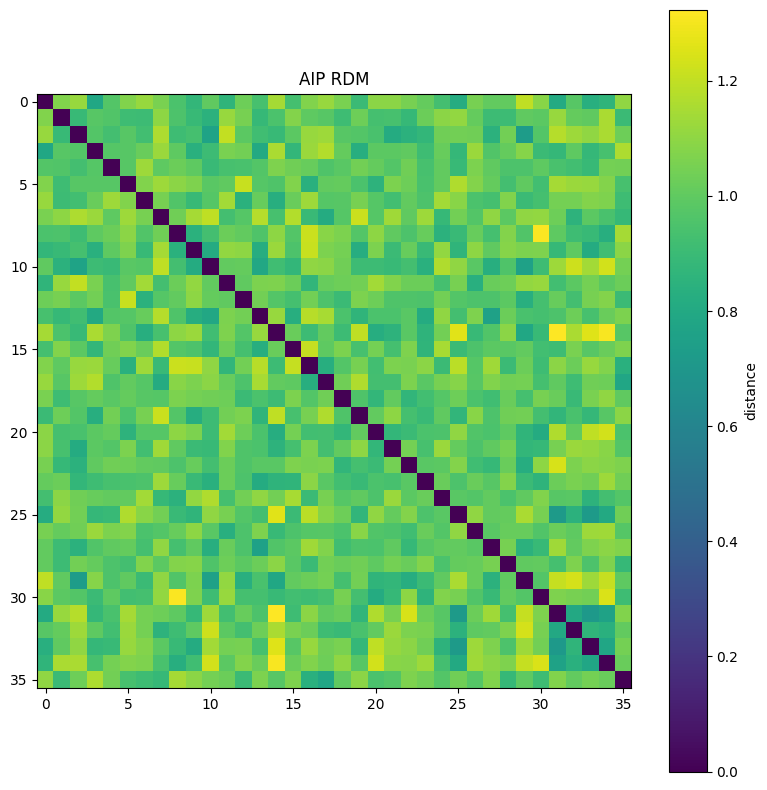

In [92]:
AIP_ids = [
    117, 1117
]

AIP_mask, AIP_data, AIP_RDM = compute_roi_rdm(
    atlas,
    selected_volumes,
    AIP_ids,
    title="AIP RDM",
    metric="correlation",
    plot=True
)

In [36]:
search_roi(df_labels, "LO")

,roi_id,name,hemi,region
19,20,L_LO1,L,LO1
20,21,L_LO2,L,LO2
158,159,L_LO3,L,LO3
199,1020,R_LO1,R,LO1
200,1021,R_LO2,R,LO2
338,1159,R_LO3,R,LO3


In [64]:
search_roi(df_labels, "PIT")

,roi_id,name,hemi,region
21,22,L_PIT,L,PIT
201,1022,R_PIT,R,PIT


In [70]:
print(atlas.shape)
print(selected_volumes.shape[:3])

(72, 91, 75)
(72, 91, 75)


ROI voxel count: 522
ROI data shape (voxels, trials): (522, 36)
RDM shape: (36, 36)


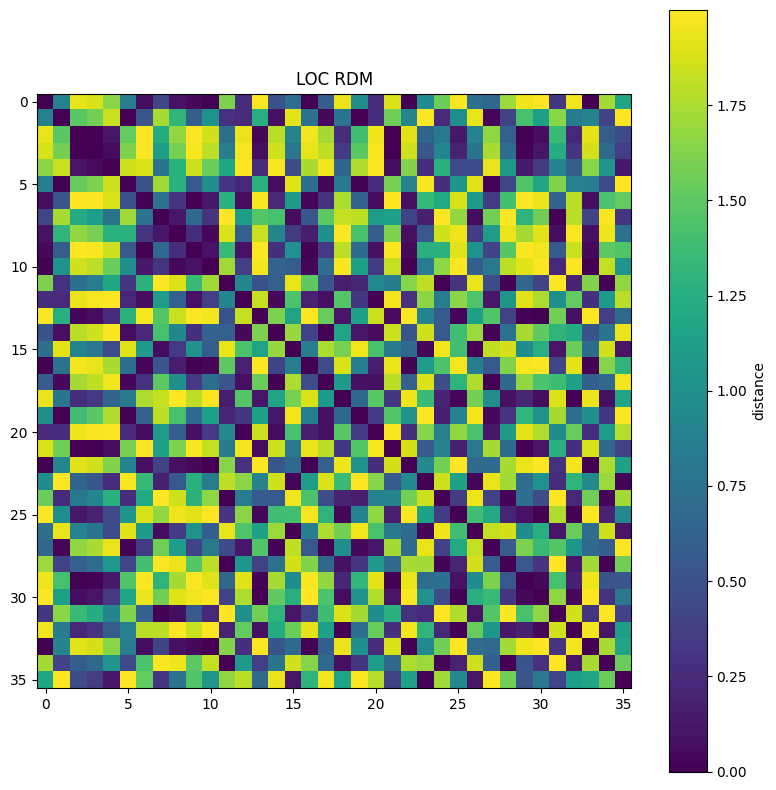

(522, 36)


In [80]:
LOC_ids = [
    20, 21, 159, 1020, 1021, 1159, 22, 1022

]

LOC_mask, LOC_data, LOC_RDM = compute_roi_rdm(
    atlas,
    selected_volumes,
    LOC_ids,
    title="LOC RDM",
    metric="correlation",
    plot=True
)

print(LOC_data.shape)

In [84]:
trial1 = LOC_data[:, 5]

print(trial1.shape)
print(trial1[:20])
print("mean:", trial1.mean())
print("std:", trial1.std())
print("min:", trial1.min())
print("max:", trial1.max())

(522,)
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
mean: 0.00020059610590324433
std: 0.004559600662955626
min: 0.0
max: 0.10427450388669968


In [85]:
trial1 = LOC_data[:, 0]
trial2 = LOC_data[:, 1]

r = np.corrcoef(trial1, trial2)[0,1]

print(r)

0.12099815745101253


In [86]:
corr = np.corrcoef(LOC_data.T)

print(corr.shape)

(36, 36)


In [90]:
print(df_sub01["concept"].value_counts())

concept
spoon     12
pencil    12
dog       12
Name: count, dtype: int64


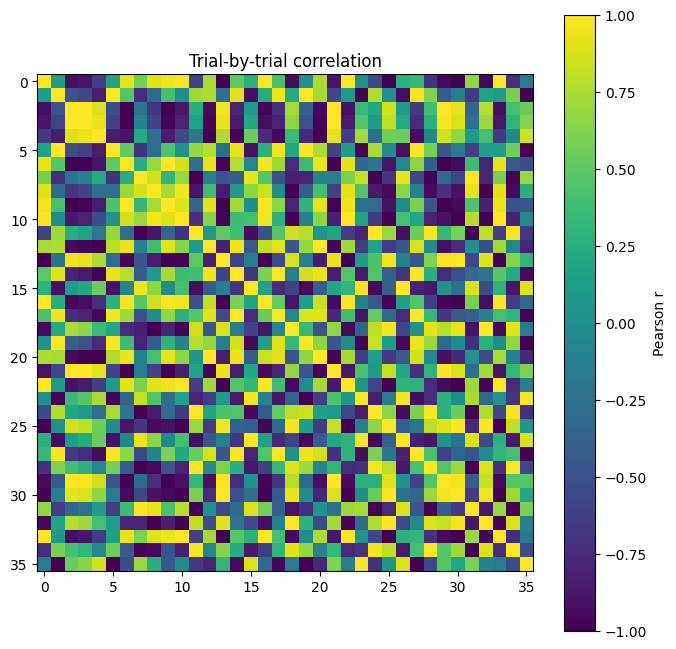

In [87]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,8))
plt.imshow(corr, vmin=-1, vmax=1)
plt.colorbar(label="Pearson r")
plt.title("Trial-by-trial correlation")
plt.show()

In [54]:
search_roi(df_labels, "V1")

,roi_id,name,hemi,region
0,1,L_V1,L,V1
152,153,L_VMV1,L,VMV1
180,1001,R_V1,R,V1
332,1153,R_VMV1,R,VMV1


ROI voxel count: 885
ROI data shape (voxels, trials): (885, 36)
RDM shape: (36, 36)


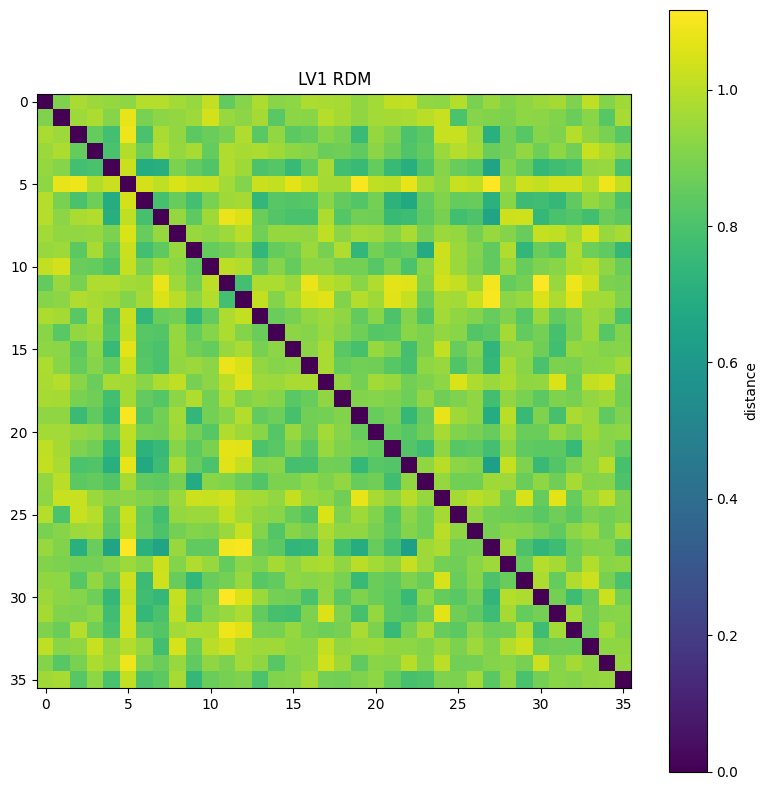

ROI voxel count: 1055
ROI data shape (voxels, trials): (1055, 36)
RDM shape: (36, 36)


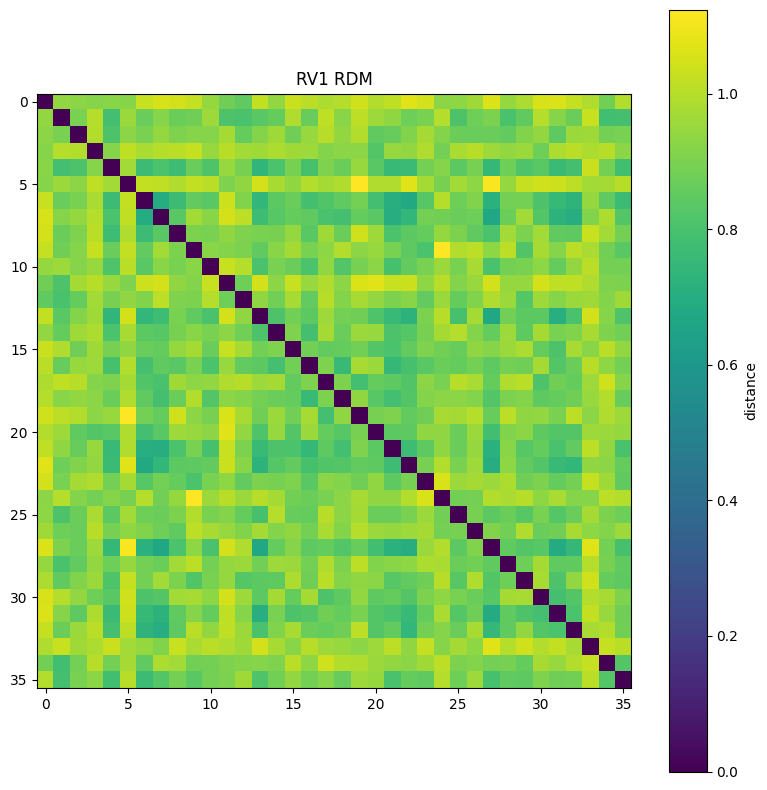

array([[0.        , 0.94056951, 0.92888259, ..., 0.98970947, 0.88411405,
        0.99496889],
       [0.94056951, 0.        , 0.8971475 , ..., 1.03113392, 0.78463135,
        0.79248225],
       [0.92888259, 0.8971475 , 0.        , ..., 0.96299293, 0.8890663 ,
        0.89576704],
       ...,
       [0.98970947, 1.03113392, 0.96299293, ..., 0.        , 1.02556986,
        1.00497695],
       [0.88411405, 0.78463135, 0.8890663 , ..., 1.02556986, 0.        ,
        0.82097403],
       [0.99496889, 0.79248225, 0.89576704, ..., 1.00497695, 0.82097403,
        0.        ]], shape=(36, 36))

In [53]:
LV1_ids = [
    1, 153
]

compute_roi_rdm(
    atlas,
    selected_volumes,
    LV1_ids,
    title="LV1 RDM",
    metric="correlation",
    plot=True
)

RV1_ids = [
    1001, 1153
]

compute_roi_rdm(
    atlas,
    selected_volumes,
    RV1_ids,
    title="RV1 RDM",
    metric="correlation",
    plot=True
)

In [59]:
V2_roi = search_roi(df_labels, "V2")
V2_roi

,roi_id,name,hemi,region
3,4,L_V2,L,V2
32,33,L_v23ab,L,v23ab
159,160,L_VMV2,L,VMV2
183,1004,R_V2,R,V2
212,1033,R_v23ab,R,v23ab
339,1160,R_VMV2,R,VMV2


3         4
32       33
159     160
183    1004
212    1033
339    1160
Name: roi_id, dtype: int64
ROI voxel count: 1664
ROI data shape (voxels, trials): (1664, 36)
RDM shape: (36, 36)


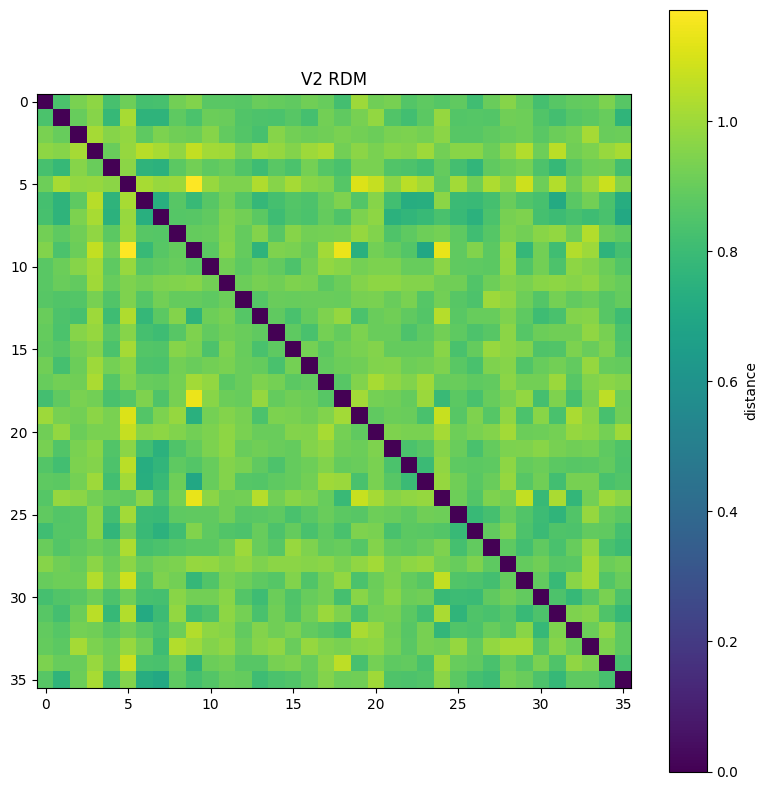

array([[0.        , 0.83706209, 0.93653104, ..., 0.89403808, 0.93831084,
        0.86694741],
       [0.83706209, 0.        , 0.90030425, ..., 0.87357356, 0.8968534 ,
        0.76742383],
       [0.93653104, 0.90030425, 0.        , ..., 1.01372943, 0.90176367,
        0.90702106],
       ...,
       [0.89403808, 0.87357356, 1.01372943, ..., 0.        , 0.94004864,
        0.88144763],
       [0.93831084, 0.8968534 , 0.90176367, ..., 0.94004864, 0.        ,
        0.82856574],
       [0.86694741, 0.76742383, 0.90702106, ..., 0.88144763, 0.82856574,
        0.        ]], shape=(36, 36))

In [62]:
V2_ids = V2_roi["roi_id"]
print(V2_ids)

compute_roi_rdm(
    atlas,
    selected_volumes,
    V2_ids,
    title="V2 RDM",
    metric="correlation",
    plot=True
)

In [55]:
search_roi(df_labels, "V4")

,roi_id,name,hemi,region
5,6,L_V4,L,V4
155,156,L_V4t,L,V4t
185,1006,R_V4,R,V4
335,1156,R_V4t,R,V4t


ROI voxel count: 580
ROI data shape (voxels, trials): (580, 36)
RDM shape: (36, 36)


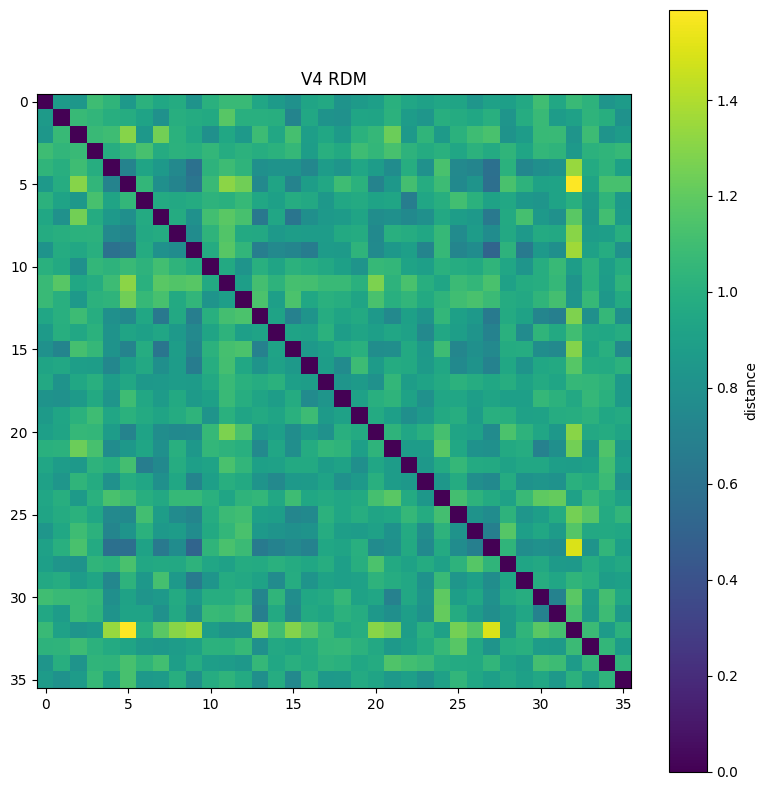

array([[0.        , 0.86562969, 0.840035  , ..., 1.02364928, 0.82861366,
        0.87212775],
       [0.86562969, 0.        , 1.06725104, ..., 1.03158082, 0.99656683,
        0.8075645 ],
       [0.840035  , 1.06725104, 0.        , ..., 1.09077685, 0.81985433,
        0.87294324],
       ...,
       [1.02364928, 1.03158082, 1.09077685, ..., 0.        , 1.05171471,
        0.87478244],
       [0.82861366, 0.99656683, 0.81985433, ..., 1.05171471, 0.        ,
        1.03035392],
       [0.87212775, 0.8075645 , 0.87294324, ..., 0.87478244, 1.03035392,
        0.        ]], shape=(36, 36))

In [57]:
V4_ids = [
    6, 156, 1006, 1156
]

compute_roi_rdm(
    atlas,
    selected_volumes,
    V4_ids,
    title="V4 RDM",
    metric="correlation",
    plot=True
)

In [52]:
search_roi(df_labels, "PF")

,roi_id,name,hemi,region
104,105,L_PFcm,L,PFcm
115,116,L_PFt,L,PFt
146,147,L_PFop,L,PFop
147,148,L_PF,L,PF
148,149,L_PFm,L,PFm
284,1105,R_PFcm,R,PFcm
295,1116,R_PFt,R,PFt
326,1147,R_PFop,R,PFop
327,1148,R_PF,R,PF
328,1149,R_PFm,R,PFm


ROI voxel count: 3531
ROI data shape (voxels, trials): (3531, 36)
RDM shape: (36, 36)


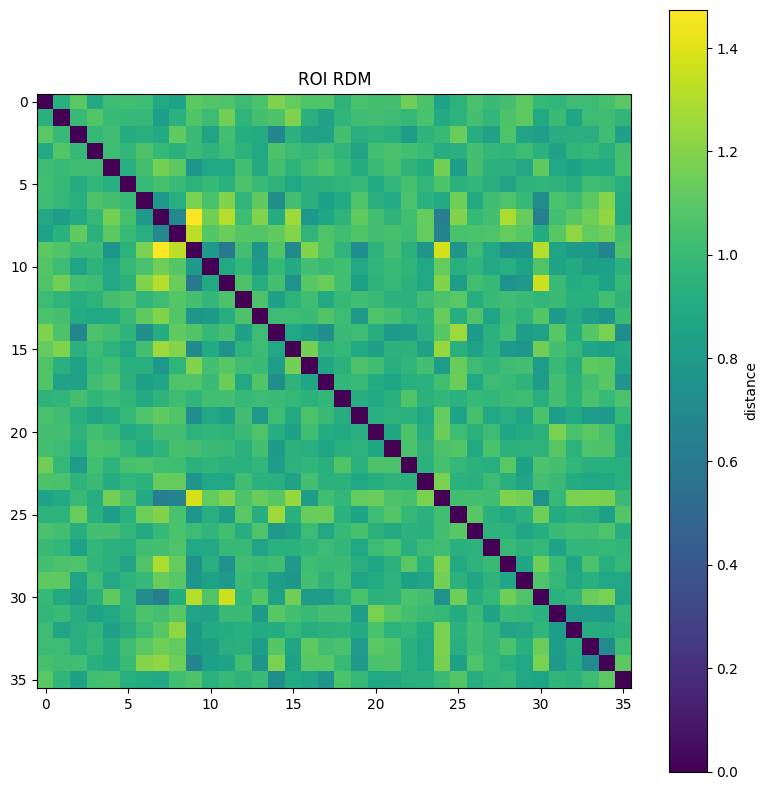

array([[0.        , 0.93493814, 1.09703363, ..., 1.01012885, 1.04441555,
        1.09452107],
       [0.93493814, 0.        , 0.99608818, ..., 1.0115804 , 1.02182004,
        0.96919648],
       [1.09703363, 0.99608818, 0.        , ..., 0.93043893, 1.02157432,
        0.84403179],
       ...,
       [1.01012885, 1.0115804 , 0.93043893, ..., 0.        , 0.70976467,
        1.01590116],
       [1.04441555, 1.02182004, 1.02157432, ..., 0.70976467, 0.        ,
        1.10292126],
       [1.09452107, 0.96919648, 0.84403179, ..., 1.01590116, 1.10292126,
        0.        ]], shape=(36, 36))

In [33]:
roi_ids = [
    105, 116, 143, 147, 148, 149, 150, 151
]

compute_roi_rdm(
    atlas,
    selected_volumes,
    roi_ids,
    title="ROI RDM",
    metric="correlation",
    plot=True
)

   roi_id    name hemi region
0      18   L_FFC    L    FFC
1    1018   R_FFC    R    FFC
2     163   L_VVC    L    VVC
3    1163   R_VVC    R    VVC
4     153  L_VMV1    L   VMV1
5     154  L_VMV3    L   VMV3
6     160  L_VMV2    L   VMV2
7    1153  R_VMV1    R   VMV1
8    1154  R_VMV3    R   VMV3
9    1160  R_VMV2    R   VMV2
ROI voxel count: 2424
ROI data shape (voxels, trials): (2424, 36)
RDM shape: (36, 36)


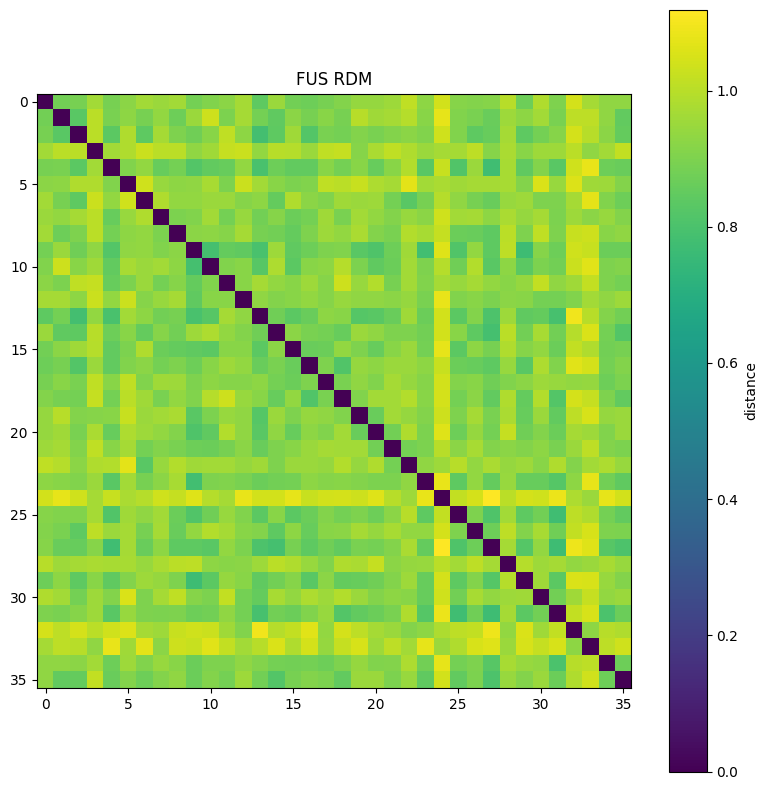

(array([[[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],
 
        [[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False]],
 
        [[False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         [False, False, False, ..., False, False, False],
         ...,
         [False, False, False, ..., False, False, False],
         [False, False, 

In [102]:
FUS_roi = pd.concat([
    search_roi(df_labels, "FFC"),
    search_roi(df_labels, "VVC"),
    search_roi(df_labels, "VMV")
], ignore_index=True)

print(FUS_roi)

FUS_ids = FUS_roi["roi_id"]

compute_roi_rdm(
    atlas,
    selected_volumes,
    FUS_ids,
    title="FUS RDM",
    metric="correlation",
    plot=True
)